# Reading baryons off the sky: a field-level emulator for the gas–cosmology connection

## 1. Introduction

**The problem.** On the scales where the next decade of cosmology will be decided —
$k\sim1$–$10\,h\,\mathrm{Mpc}^{-1}$ — the matter distribution is not shaped by
gravity alone. Energy injected by supernovae and accreting supermassive black holes
drives gas out of halos and far beyond their virial radii, suppressing the
small-scale matter power spectrum by up to $\sim\!20\%$
($S(k)\equiv P_{\rm hydro}(k)/P_{\rm DMO}(k)\to0.8$ at $k\sim10\,h\,\mathrm{Mpc}^{-1}$;
van Daalen et al. 2020). This baryonic suppression is the **leading astrophysical
systematic for Stage-IV weak-lensing surveys** (Rubin/LSST, *Euclid*, *Roman*), and
the model-to-model spread in its amplitude is itself a large part of the cosmic-shear
error budget. The same feedback sets the thermodynamics of the circum- and
intra-cluster medium and the partition of each halo's mass into dark matter, gas, and
stars. Yet the quantity that most compactly encodes all of this — the halo baryon
fraction $f_b=M_{\rm b}/M_{\rm tot}$ and, more generally, the *spatial redistribution*
of the gas — is **neither directly observable nor calculable from first principles**:
a survey measures line-of-sight integrals of the gas thermodynamics (thermal and
kinetic Sunyaev–Zel'dovich, X-ray surface brightness), while the feedback that governs
the redistribution is sub-grid physics, implemented differently by every simulation.

**What is usually done, and why it is not enough.** Two strategies dominate. The
first runs hydrodynamic simulations under a chosen sub-grid feedback model — but no
single model is correct, and the dispersion *between* models is precisely the
uncertainty one is trying to quantify. The second measures **stacked profiles** —
tSZ $Y(r)$, X-ray $S_X(r)$, kSZ — around halo samples and fits them with parametric
prescriptions (the halo model, "baryonification," GNFW pressure profiles). Both
approaches share two structural limits. They compress the data to a handful of
radially-averaged numbers, discarding the morphology, halo-to-halo covariance,
selection response, and instrument forward model that a real measurement actually
carries; and they bridge *what is measured* (gas thermodynamics) to *what is wanted*
(the mass partition, $f_b$, the suppression $S(k)$) only through a parametric model
whose feedback assumptions are then inherited by every downstream conclusion.

**What has changed.** Two developments make a different route feasible. CAMELS
(Villaescusa-Navarro et al. 2021) provides thousands of (magneto)hydrodynamic
simulations that systematically sweep the feedback prior, turning "model uncertainty"
into a sampled, learnable space. And conditional generative models — diffusion and
flow matching — can now emulate full two-dimensional *fields*, rather than summary
statistics, quickly and probabilistically. Together they open the door to
**field-level, forward-modeled inference**: learn the conditional distribution of the
baryon field given the dark matter and the feedback parameters, then bring *that* into
contact with data — at the field level, before any compression.

**Our approach.** We use **BIND**, a conditional flow-matching emulator that paints the
full baryonic field — gas, stars, hydro dark matter, and the gas thermodynamics
($y_{\rm tSZ}, T, K, P_e$) — onto any dark-matter-only (DMO) map, conditioned on a
35-dimensional cosmology-plus-feedback vector. Because BIND is field-level *and* can
repaint the **same** halos under different feedback with common random numbers, it
offers two things no single hydrodynamic suite provides jointly. First, *controlled
experiments*: hold the halos, cosmology, and initial noise fixed and vary **only**
feedback, following the response continuously from per-halo gas content all the way up
to the box $P(k)$. Second, a forward-modeled, **parameter-free inverse**: because the
emulator carries the full joint field across feedback space, observables can be mapped
to unobserved physical state *without ever estimating the sub-grid feedback parameters*
$\theta$ of any one model — they enter only as a training label, never as something we
must measure.

**Results.** This produces a chain of results that turns cluster gas observables into a
probe of the otherwise-hidden baryon budget. **(i)** BIND reproduces the baryonic
**scaling relations and their intrinsic scatter and cross-correlations** against
held-out hydrodynamic truth — the emulator is faithful at the per-halo level, not only
on average. **(ii)** We then show — and the remainder of this notebook makes the
argument precise and validates it on the CAMELS feedback factorial — that the
field-level representation is *necessary*: a profile-regression summary is one moment
of a single marginal of the field posterior, provably blind to the covariance,
instrument response, selection, multi-probe coherence, and morphology that real
inference relies on. **(iii)** Built on that foundation, a stacked tSZ$+$X-ray
*profile* predicts the baryon-fraction profile $f_b(r)$ at fixed mass with $69$–$80\%$
scatter reduction on **feedback settings never seen in training**, and — applied to
genuine CAMELS hydrodynamic truth — recovers $f_b(r)$ to $\mathrm{RMS}\simeq0.004$
(including the feedback-evacuated core, robust to $\sim\!20\%$ stacking noise): an
unmeasurable physical state read off realistic data, parameter-free. **(iv)** Finally,
the same field-level machinery decomposes **which halos drive the *variance* of
$S(k)$** across the feedback prior — whether the leading weak-lensing systematic is set
by halo mass alone or by gas content at fixed mass — connecting the observable gas
directly to the cosmological signal it contaminates.

**This paper.** Section 2 sets out the methods — the BIND field emulator, the controlled
Sobol feedback suite, and the observables with their instrument forward model. Section 3
then establishes the enabling claim, that the field and not the profile is the right object,
through a sequence of controlled demonstrations on the $256$-design $\times\,1111$-halo
factorial, each exhibiting a functional of the field (covariance, beam forward-modeling,
selection, multi-probe coherence, morphology) that a profile mean cannot supply. Section 4
*uses* the emulator: it is faithful to hydrodynamic truth, it links the painted halo gas to
the matter power-spectrum suppression that limits weak lensing, and it identifies which halos
carry that systematic. Section 5 runs the inverse — reading the baryon-fraction profile off
realistic mock $(Y,S_X)$ observations and recovering CAMELS hydrodynamic truth — and discusses
the path to real data. Throughout, observables are forward-modeled through the same beams a
real survey applies (ACT/*Planck*-scale tSZ, with kSZ and X-ray as companions), so the painted
maps connect directly to existing CMB and X-ray cluster stacks; the step from CAMELS
hydrodynamic truth to the sky is one of *data*, not of *method*. Every result is provisional to
one sub-grid family at fixed cosmology, and we are explicit (§5.3) about the off-grid and
instrumental validations that remain.

## 2. Methods

We summarise everything the analysis computes: how BIND generates fields, the
controlled feedback suite that drives every quantitative claim, the observables and
their instrument forward model, and the data products and operators loaded below.

### 2.1 The BIND field emulator

BIND is a conditional generative model of the baryon field. Writing the
dark-matter-only (DMO) projection as the condition $c$ and the 35-dimensional
cosmology$+$feedback vector as $\theta$, it samples
$$ x \sim p_\theta(x\mid c), \qquad x\in\mathbb{R}^{C\times H\times W}, $$
with $C=7$ channels $[\mathrm{DM},\mathrm{Gas},\mathrm{Stars},Y,T,S,P_e]$ on
$H{=}W{=}128$ pixel maps ($\Delta_{\rm pix}=48.83\,h^{-1}\mathrm{kpc}$). The first
three are mass surface densities; the last four are the gas thermodynamics (tSZ
Compton-$y$, mass-weighted temperature, entropy, electron pressure).

Generation is by **flow matching**. A velocity field $v_\Phi(x_t,t,c,\theta)$ is
trained so that the probability-flow ODE $\dot x_t = v_\Phi$ transports a Gaussian
prior at $t{=}0$ to the data at $t{=}1$ along the optimal-transport path
$x_t=(1-t)\,\epsilon + t\,x_1$; at inference we integrate that ODE from noise to a
sampled field. The network is a UNet whose input is the channel concatenation
$[\,x_t,\ c,\ x_{\rm large}\,]$ (noisy state, DMO condition, large-scale context),
and whose conditioning enters through adaptive group normalisation: a sinusoidal
embedding of $t$ and an encoding of $\theta$ are **summed** and predict per-channel
scale/shift in every residual block. Because $\theta$ is an input, the *same* DMO halo
can be repainted under any feedback point and — fixing the ODE's initial noise — under
**common random numbers**, which is what makes the controlled experiments below
possible. The Stars channel is emitted as an (occupancy, conditional-density) pair and
recombined at inference; all channels are trained in a per-channel $\log_{10}(1+x)$
(thermo: $\log_{10}$) standardised space — the normalisation contract that ties training
to the observables we read off here.

### 2.2 The controlled feedback suite

All quantitative claims use one suite: a fixed catalogue of $N_h=1111$ CAMELS-CV halos
($\log_{10}M_{200}\in[13,15)$, drawn from 26 IllustrisTNG CV boxes) painted under
$N_d=256$ feedback designs. The designs are a **Sobol** (quasi-random, space-filling)
sequence in the 30 astrophysical/feedback parameters of the IllustrisTNG model
(supernova winds, AGN/black-hole growth and feedback, the stellar IMF and evolution),
with the five cosmological parameters held at their CV fiducial values. Sobol sampling
fills the prior far more uniformly than i.i.d. draws, so 256 points resolve the response
over the whole feedback hypercube instead of clustering.

The experiment's power comes from what is held fixed. The 1111 halos — their DMO inputs,
cosmology, and the generator's initial noise — are **identical across all 256 designs**,
so
$$ \underbrace{\text{variation across designs}}_{\text{isolates feedback}}
   \quad\text{and}\quad
   \underbrace{\text{variation across halos at fixed design}}_{\text{isolates intrinsic scatter}} $$
are cleanly separated. This is a factorial a hydrodynamic suite cannot run — it would
require re-simulating the same initial conditions hundreds of times — and it is what lets
us attribute a change in any field statistic to feedback alone (§3) or decompose the
variance of a cosmological observable halo-by-halo (§4). Throughout we bin halos by mass
into $[13.0,13.5),[13.5,14.0),[14.0,\infty)$ ($828/232/51$ halos).

### 2.3 Observables, projections, and the instrument forward model

Every scientific summary is a **functional** $\mathcal{O}[x]$ of the painted field. Two
families recur. *Radial profiles* apply the azimuthal-average operator about the halo
centre, $(\mathcal{A}_r x)(r)=\langle x(u)\rangle_{|u-u_0|=r}$, to a chosen channel — the
tSZ profile $Y(r)$, the X-ray surface-brightness proxy
$S_X(r)\propto \rho_{\rm gas}^2\sqrt{T}$, or the gas/entropy/pressure profiles. *Aperture
scalars* integrate a channel inside $R_{200}$ — the aperture tSZ $Y_{200}$, the baryon
fraction $f_b=M_{\rm b}/M_{\rm tot}$, and a kSZ optical-depth proxy $\tau\propto$ aperture
gas mass. Stacked profiles are exact halo sums $Y(r)=\sum_i y_i(r)\big/\sum_i$, binned in
12 logarithmic radii out to a few $\times R_{200}$.

A real measurement never sees $x$. It sees a **beam-convolved, mis-centred, noisy** map,
$$ y_{\rm obs} = B\star(\mathcal{T}_\delta\,x) + n, $$
where $B$ is the instrument beam (a Gaussian of FWHM set by the survey), $\mathcal{T}_\delta$
is a random recentring drawn from the centroiding error, and $n$ is noise. We forward-model
through the ACT/*Planck* range — beam FWHM $\in\{0,1.0,1.6,2.5\}$ arcmin and a centroiding
$\sigma_{\rm mc}=150\,h^{-1}\mathrm{kpc}$ — exactly the operators a stacking pipeline applies,
so the painted maps meet data on the same footing. This convolution is the crux of §3.4: $B$
acts on the 2D field and, for real aspherical, mis-centred halos, does **not** commute with
the azimuthal average. Figure M shows the Sobol design coverage and these beam kernels.

### 2.4 Data products and operators

The controlled experiment fixes a catalog of $N_h=1111$ halos (the *same* DMO
inputs) and paints it under $N_d=256$ Sobol parameter sets $\{\theta_d\}$. Thus
**variation across designs isolates astrophysics** (feedback response at fixed
structure), and **variation across halos at fixed design isolates intrinsic
scatter** (the irreducible object behind every stack). The geometry is
$\Delta_{\rm pix}=48.83\,h^{-1}\mathrm{kpc}$, channels
$[\mathrm{DM},\mathrm{Gas},\mathrm{Stars},Y,T,S,P]$, apertures are circular in
$R_{200}$, and the mass bins are
$\log_{10}M_{200}\in[13.0,13.5),[13.5,14.0),[14.0,\infty)$ with $828/232/51$
halos.

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
import scienceplots

# Academic style: scienceplots, no explicit fontsizes, no titles anywhere.
plt.style.use(['science', 'no-latex'])

S = Path('/mnt/home/mlee1/ceph/sobol_ss_cv')
FIG = Path('figures/paper'); FIG.mkdir(parents=True, exist_ok=True)

# ---- per-halo scalar observables (small, all designs) ---------------------
cube = np.load(S / 'cube.npz', allow_pickle=True)
obs, on = cube['obs'], list(cube['obs_names'])          # (256,1111,8)
M200 = np.asarray(cube['M200'], float)                  # (1111,)
R200 = np.asarray(cube['R200'], float)                  # (1111,)
lM = np.log10(M200)
design_phys = np.asarray(cube['design_phys'], float)    # (256,35)
param_names = list(cube['param_names'])

ex = np.load(S / 'obs_fb_extra.npz', allow_pickle=True)
EX, en = ex['extra'], list(ex['extra_names'])           # (256,1111,4)

Y   = obs[:, :, on.index('Y200')].astype(float)         # (256,1111) tSZ aperture
fb  = EX[:, :, en.index('f_b')].astype(float)           # (256,1111) target
tau = EX[:, :, en.index('tau_ksz')].astype(float)       # (256,1111) kSZ proxy

# mass bin index per halo
EDGES = [13.5, 14.0]
mb = np.digitize(lM, EDGES)                              # 0,1,2
MLBL = ['[13.0,13.5)', '[13.5,14.0)', '[14.0,+)']
NB = len(MLBL)

# ---- transparent gas morphology: CAS asymmetry cache ----------------------
#   built by tools/compute_gas_asymmetry.py (180-deg rotational asymmetry of the
#   Gas channel within R200, centroid-centered; == 0 for any axisymmetric field).
ZA = np.load(S / 'gas_asymmetry.npz', allow_pickle=True)
ASYM = ZA['A'].astype(float)                             # (256,1111)
ASYM = np.where(np.isnan(ASYM), np.nanmean(ASYM, 0), ASYM)

# ---- mass-binned stacked design profiles (the regression "foil" data) -----
sp = np.load(S / 'stacked_profiles.npz', allow_pickle=True)
r_kpc = np.asarray(sp['r_kpc'], float)                   # (12,)
Yprof  = np.asarray(sp['Y'], float)                      # (256,3,12)
fbprof = np.asarray(sp['fb'], float)                     # (256,3,12)
gc = np.load(S / 'gas_column_profile.npz', allow_pickle=True)
gas_mean = np.asarray(gc['gas_mean'], float)            # (256,3,12) kSZ proxy

# ---- one design's full fields, for field-level figures --------------------
PIX_KPC = 48.828125
CH = ['DM', 'Gas', 'Stars', 'Y', 'T', 'S', 'P']
DFIELD = 0
G = np.load(S / 'maps' / f'gen_design{DFIELD:04d}.npz')['generated']  # (1111,7,128,128)

# ---- beam-aware forward-model results (precomputed) -----------------------
BEAM = json.load(open('figures/observable_fb_beam_aware/beam_aware_results.json'))

# ---- radial-profile operator A_r on 128^2 maps ----------------------------
H = G.shape[-1]
yy, xx = np.mgrid[0:H, 0:H]
rr_kpc = np.hypot(yy - H / 2 + 0.5, xx - H / 2 + 0.5) * PIX_KPC
# geometric bin edges around the 12 stacked-profile radii
_logr = np.log10(r_kpc)
_edges = np.concatenate([[10 ** (_logr[0] - (_logr[1] - _logr[0]) / 2)],
                         10 ** ((_logr[1:] + _logr[:-1]) / 2),
                         [10 ** (_logr[-1] + (_logr[-1] - _logr[-2]) / 2)]])
binidx = np.digitize(rr_kpc, _edges) - 1                 # -1..12
NR = len(r_kpc)
masks = [(binidx == b) for b in range(NR)]
mask_n = np.array([m.sum() for m in masks])
RV = np.where(mask_n > 0)[0]            # populated radial bins (drop empty core bin)
rkpc_v = r_kpc[RV]

def radial_profile(maps):
    '''Azimuthal average A_r of a stack maps[...,H,H] -> [...,NR];
    empty radial bins return NaN.'''
    maps = np.asarray(maps)
    out = np.full(maps.shape[:-2] + (NR,), np.nan)
    for b, m in enumerate(masks):
        if mask_n[b]:
            out[..., b] = maps[..., m].mean(axis=-1)
    return out

def sym_image(Pv):
    '''Axisymmetric 2D reconstruction from a profile Pv defined on the populated
    radii rkpc_v (what a profile-only emulator implicitly assumes x looks like).'''
    return np.interp(rr_kpc, rkpc_v, Pv, left=Pv[0], right=Pv[-1])

print('designs x halos        :', Y.shape)
print('field tensor (design 0):', G.shape, G.dtype)
print('halos per mass bin     :', [int((mb == b).sum()) for b in range(NB)])
print('radial bins (kpc/h)    :', np.round(r_kpc, 1))

designs x halos        : (256, 1111)
field tensor (design 0): (1111, 7, 128, 128) float32
halos per mass bin     : [828, 232, 51]
radial bins (kpc/h)    : [  56.8   76.9  104.2  141.1  191.   258.7  350.3  474.3  642.2  869.6
 1177.6 1594.5]


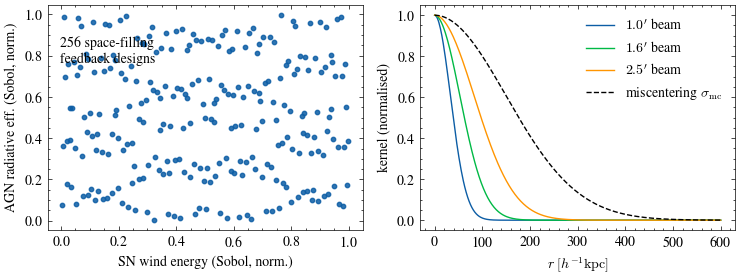

Sobol designs: 256 | beam FWHM [arcmin]: [0.0, 1.0, 1.6, 2.5]


In [2]:
# Figure M -- the controlled suite: Sobol design coverage and the survey beams.
design_norm = np.asarray(cube['design_norm'], float)        # (256,30) in [0,1]
astro_names = [str(s) for s in cube['astro_names']]
ix = astro_names.index('WindEnergyIn1e51erg')
jx = (astro_names.index('BlackHoleRadiativeEfficiency')
      if 'BlackHoleRadiativeEfficiency' in astro_names else 1)
fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.0))
axes[0].scatter(design_norm[:, ix], design_norm[:, jx], s=10, c='C0', alpha=0.85)
axes[0].set_xlabel('SN wind energy (Sobol, norm.)')
axes[0].set_ylabel('AGN radiative eff. (Sobol, norm.)')
axes[0].annotate('256 space-filling\nfeedback designs', (0.04, 0.86),
                 xycoords='axes fraction', va='top')
rr_b = np.linspace(0, 600, 400)                              # h^-1 kpc
smc = BEAM['sigma_mc_kpc_h']
for bm in BEAM['beams']:
    sb = np.sqrt(max(bm['sigma_total_kpc_h'] ** 2 - smc ** 2, 0.0))
    if sb > 0:
        kern = np.exp(-rr_b ** 2 / (2 * sb ** 2))
        axes[1].plot(rr_b, kern / kern.max(),
                     label=r"$%.1f'$ beam" % bm['fwhm_arcmin'])
axes[1].plot(rr_b, np.exp(-rr_b ** 2 / (2 * smc ** 2)), 'k--',
             label=r'miscentering $\sigma_{\rm mc}$')
axes[1].set_xlabel(r'$r\;[h^{-1}\mathrm{kpc}]$')
axes[1].set_ylabel('kernel (normalised)'); axes[1].legend()
fig.tight_layout()
fig.savefig(FIG / 'figM_methods.png', dpi=200, bbox_inches='tight')
plt.show()
print('Sobol designs:', design_norm.shape[0],
      '| beam FWHM [arcmin]:', [b['fwhm_arcmin'] for b in BEAM['beams']])

## 3. The case for field-level emulation

The methods in place, we establish the central methodological claim: for baryon emulation
the **field**, not the stacked profile, is the right object. A natural objection frames the
stakes. If the science target is a stacked observable such as the baryon fraction $f_b(r)$,
one could skip the field and simply *regress* a stacked profile (e.g. the tSZ signal $Y(r)$)
onto $f_b(r)$. We show, on the controlled $256$-design $\times\,1111$-halo suite, that this
profile-regression **foil** is not merely less convenient but structurally insufficient.

Make it precise. Any summary statistic is a **functional** $\mathcal{O}[x]$ of the field, and a
radial profile is the azimuthal-average operator $\mathcal{A}_r$. A profile-regression emulator
learns a single object, the conditional mean $g:\, P_Y \mapsto \mathbb{E}[f_b\mid P_Y]$ — the
*first moment of a one-dimensional marginal slice* of $p_\theta(x\mid c)$. Sections 3.1–3.8
exhibit six functionals of $p_\theta$ that the science requires and that this slice cannot
supply:

1. **(Foil)** the mean profile$\to f_b$ relation itself — which the field model contains as a
   marginal;
2. the **irreducible halo-to-halo covariance** that sets every stacked error bar,
   $\mathrm{Cov}[\hat P]=\tfrac1N\,\mathrm{Cov}_{\rm halo}[P]+\mathrm{Cov}_{\rm noise}$;
3. the **instrument forward model** — beam $\star$ field $+$ miscentering — which acts on the
   *2D field* and **does not commute** with azimuthal averaging;
4. **selection / Eddington bias**, which acts on the *observable field*;
5. the **joint cross-covariance** of correlated probes
   ($\mathrm{corr}(Y,\tau_{\rm kSZ})\!\approx\!0.96$, i.e. *not* independent);
6. **angular (morphological) information** $A[x]$ that the radial profile discards by
   construction, yet that responds to feedback in a controlled test.

Each is computed below from real BIND outputs. The conclusion is structural: the regression
emulator is the field model *restricted to a single moment of a single marginal*; the remaining
science lives in the rest of $p_\theta$.

### 3.1 The object and the foil

BIND draws fields $x\sim p_\theta(x\mid c)$. Every scientific summary is a
**functional** $\mathcal{O}[x]\in\mathbb{R}^k$ of that field. A radial profile is
the azimuthal-average operator acting on a chosen channel,

$$
(\mathcal{A}_r\,x)(r)\;=\;\big\langle x(u)\big\rangle_{|u-u_0|=r},
$$

and the aperture scalars used below (e.g. $Y_{200}$, $f_b$, $\tau_{\rm kSZ}$) are
$\mathcal{O}[x]=\int_{|u|<R_{200}} x\,\mathrm d u$ on the appropriate channel.

A **profile-regression emulator** is, by construction, a single deterministic map

$$
g:\;P_Y \;\longmapsto\; \mathbb{E}\!\left[f_b \,\middle|\, P_Y\right],
\qquad P_Y \equiv \mathcal{A}_r\,x^{(Y)},
$$

i.e. *the first moment of the one-dimensional conditional* $p(f_b\mid P_Y)$. It is
a legitimate and useful object — it is the **foil** of this paper — but it is
exactly one slice of one marginal of $p_\theta$. Sections 3.2–3.7 show that the
science needs functionals living elsewhere in $p_\theta$: second moments
($\mathrm{Cov}_{\rm halo}$), non-commuting forward operators (beam $B\star$),
conditioning on the observable (selection), cross-probe moments
($\mathrm{Cov}(Y,\tau)$), and angular information ($\mathcal{A}$ discards it).

Figure 1 shows a single painted halo across all seven channels: this $7\times
128\times 128$ object is what BIND models; the profile is one azimuthal collapse
of one of these panels.

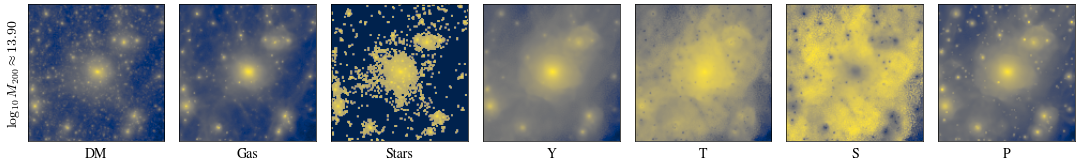

A profile is one azimuthal average of one of these 7 panels; BIND models the full joint field.


In [3]:
# Figure 1 -- the generative object: one halo, seven channels.
hh = np.argmin(np.abs(lM - 13.9))           # a ~10^13.9 halo, well resolved
fig, axes = plt.subplots(1, 7, figsize=(11, 1.9))
for k, ax in enumerate(axes):
    img = G[hh, k]
    img = np.log10(img - img.min() + 1e-8) if img.min() <= 0 else np.log10(img)
    ax.imshow(img, origin='lower', cmap='cividis')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(CH[k])
axes[0].set_ylabel(r'$\log_{10}M_{200}\approx%.2f$' % lM[hh])
fig.tight_layout()
fig.savefig(FIG / 'fig1_field_channels.png', dpi=200, bbox_inches='tight')
plt.show()
print('A profile is one azimuthal average of one of these 7 panels;'
      ' BIND models the full joint field.')

### 3.2 The foil works — and the field model contains it

Before arguing for the field model we must concede the foil's strength: across
the 256 designs, the stacked $Y(r)$ profile *does* predict the stacked $f_b(r)$
response to feedback. We fit the linear regression

$$
\widehat{f_b}(r)\;=\;g\big(P_Y\big),\qquad
g\in\mathrm{Ridge},
$$

with **out-of-fold** (5-fold) design splits, separately per mass bin, and measure
the fraction of design-to-design variance it removes,

$$
\mathcal{R}\;=\;1-\frac{\big\langle(f_b-\widehat{f_b})^2\big\rangle}
{\big\langle(f_b-\langle f_b\rangle)^2\big\rangle}.
$$

Adding the kSZ gas-column profile as a second predictor raises $\mathcal{R}$, as
expected. This is the regression emulator at its best. The crucial point for what
follows: this map is *recovered* by the field model as the conditional mean of
$\mathcal{A}_r x$ — it is a marginal of $p_\theta$, not something the field model
lacks.

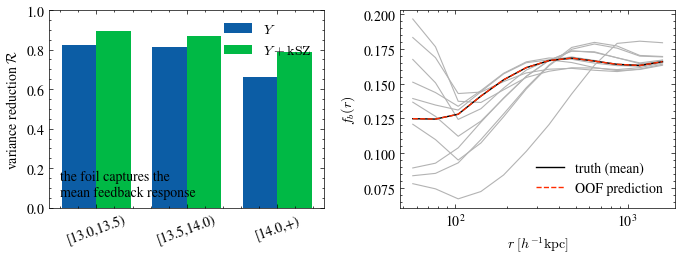

 [13.0,13.5)  R(Y)=0.82   R(Y+kSZ)=0.90
 [13.5,14.0)  R(Y)=0.81   R(Y+kSZ)=0.87
    [14.0,+)  R(Y)=0.66   R(Y+kSZ)=0.79


In [4]:
# Figure 2 -- the profile->f_b regression (the foil) works out-of-fold.
def oof_reduction(X, ytrue, k=5, seed=0):
    kf = KFold(k, shuffle=True, random_state=seed)
    pred = np.zeros_like(ytrue)
    for tr, te in kf.split(X):
        m = Ridge(alpha=1.0).fit(X[tr], ytrue[tr])
        pred[te] = m.predict(X[te])
    ss_res = ((ytrue - pred) ** 2).mean()
    ss_tot = ((ytrue - ytrue.mean(0)) ** 2).mean()
    return 1 - ss_res / ss_tot, pred

red_Y, red_Yk = [], []
preds = []
for b in range(NB):
    Xy = np.log10(np.clip(Yprof[:, b, :], 1e-30, None))
    Xk = np.log10(np.clip(gas_mean[:, b, :], 1e-30, None))
    yt = fbprof[:, b, :]
    rY, _ = oof_reduction(Xy, yt)
    rYk, pYk = oof_reduction(np.hstack([Xy, Xk]), yt)
    red_Y.append(rY); red_Yk.append(rYk); preds.append(pYk)

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.8))
# (a) reduction bars
xb = np.arange(NB); w = 0.38
axes[0].bar(xb - w / 2, red_Y, w, label=r'$Y$')
axes[0].bar(xb + w / 2, red_Yk, w, label=r'$Y+\mathrm{kSZ}$')
axes[0].set_xticks(xb); axes[0].set_xticklabels(MLBL, rotation=20)
axes[0].set_ylabel(r'variance reduction $\mathcal{R}$')
axes[0].set_ylim(0, 1); axes[0].legend()
axes[0].annotate('the foil captures the\nmean feedback response',
                 (0.04, 0.06), xycoords='axes fraction')
# (b) predicted vs truth f_b profiles (mid mass bin, held-out)
b = 1
for d in range(0, 256, 28):
    axes[1].plot(r_kpc, fbprof[d, b, :], color='0.7', lw=0.8)
axes[1].plot(r_kpc, fbprof[:, b].mean(0), 'k-', label='truth (mean)')
axes[1].plot(r_kpc, preds[b].mean(0), 'C3--', label='OOF prediction')
axes[1].set_xscale('log')
axes[1].set_xlabel(r'$r\;[h^{-1}\mathrm{kpc}]$')
axes[1].set_ylabel(r'$f_b(r)$'); axes[1].legend()
fig.tight_layout()
fig.savefig(FIG / 'fig2_foil_regression.png', dpi=200, bbox_inches='tight')
plt.show()
for b in range(NB):
    print(f'{MLBL[b]:>12}  R(Y)={red_Y[b]:.2f}   R(Y+kSZ)={red_Yk[b]:.2f}')

### 3.3 Irreducible scatter: the field gives the distribution, the foil gives one moment

A stacked profile is an estimator. For $N$ halos,

$$
\hat P \;=\; \frac1N\sum_{i=1}^N P_i,
\qquad
\mathrm{Cov}[\hat P]\;=\;\frac1N\,\mathrm{Cov}_{\rm halo}[P]\;+\;\mathrm{Cov}_{\rm noise},
$$

so **every error bar and every radial bin–bin correlation in a stacking analysis
is set by $\mathrm{Cov}_{\rm halo}[P]$** — the halo-to-halo covariance of the
field at fixed parameters. The foil $g$ predicts $\mathbb{E}[f_b\mid P_Y]$ and is
*structurally silent* about $\mathrm{Cov}_{\rm halo}$; the field model produces it
by sampling halos.

We quantify the scalar version directly. At **fixed design** (fixed $\theta$,
removing all astrophysics), the intrinsic baryon-fraction scatter is
$\sigma(f_b\mid\theta,M)$. Conditioning each halo on its *own* observed
$Y_{200}$ — the most a per-object emulator could exploit — leaves a residual
$\sigma(f_b\mid\theta,M,Y)$:

$$
\sigma_{\rm cond}=\Big\langle \mathrm{std}\big(f_b-\mathbb{E}[f_b\mid Y]\big)\Big\rangle_{\theta},
$$

averaged over designs. The residual is *most* of the scatter, especially at high
mass. We also show the radial bin–bin **correlation matrix** of $Y(r)$ within one
design (strong off-diagonal structure the mean profile discards) and verify the
$1/\sqrt N$ stacking law.

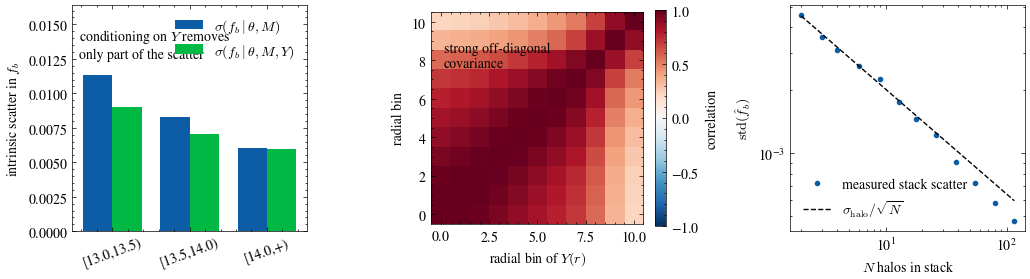

 [13.0,13.5)  sigma_marg=0.0113  sigma_cond=0.0090  (20% removed by Y)
 [13.5,14.0)  sigma_marg=0.0083  sigma_cond=0.0070  (16% removed by Y)
    [14.0,+)  sigma_marg=0.0061  sigma_cond=0.0059  (2% removed by Y)


In [5]:
# Figure 3 -- intrinsic covariance the mean-profile emulator cannot supply.
sig_marg = np.zeros(NB); sig_cond = np.zeros(NB)
for b in range(NB):
    sel = (mb == b)
    sm, sc = [], []
    for d in range(256):
        y = fb[d, sel]
        x = np.log10(np.clip(Y[d, sel], 1e-30, None))
        sm.append(y.std())
        A = np.polyfit(x, y, 1)
        sc.append((y - np.polyval(A, x)).std())
    sig_marg[b] = np.mean(sm); sig_cond[b] = np.mean(sc)

# radial covariance of Y(r) within one design + mid bin, from the fields
b = 1
selh = np.where(mb == b)[0]
Yr = radial_profile(G[selh, CH.index('Y')])[:, RV]      # (n, n_valid)
Yr = np.log10(np.clip(Yr, 1e-30, None))
Ccorr = np.corrcoef(Yr.T)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.0))
# (a) marginal vs conditional scatter
xb = np.arange(NB); w = 0.38
axes[0].bar(xb - w / 2, sig_marg, w, label=r'$\sigma(f_b\mid\theta,M)$')
axes[0].bar(xb + w / 2, sig_cond, w, label=r'$\sigma(f_b\mid\theta,M,Y)$')
axes[0].set_xticks(xb); axes[0].set_xticklabels(MLBL, rotation=20)
axes[0].set_ylim(0, sig_marg.max() * 1.45)
axes[0].set_ylabel(r'intrinsic scatter in $f_b$')
axes[0].legend(loc='upper right')
axes[0].annotate('conditioning on $Y$ removes\nonly part of the scatter',
                 (0.03, 0.90), xycoords='axes fraction', va='top')
# (b) radial correlation matrix
im = axes[1].imshow(Ccorr, origin='lower', cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_xlabel(r'radial bin of $Y(r)$'); axes[1].set_ylabel(r'radial bin')
fig.colorbar(im, ax=axes[1], fraction=0.046, label='correlation')
axes[1].annotate('strong off-diagonal\ncovariance', (0.06, 0.86),
                 xycoords='axes fraction', va='top', color='k')
# (c) 1/sqrt(N) law for the stack
Ns = np.unique(np.round(np.geomspace(2, len(selh) // 2, 12)).astype(int))
rng = np.random.default_rng(0)
fbsel = fb[DFIELD, selh]
emp = [np.std([fbsel[rng.choice(len(selh), n, replace=False)].mean()
               for _ in range(400)]) for n in Ns]
axes[2].loglog(Ns, emp, 'o', ms=3, label='measured stack scatter')
axes[2].loglog(Ns, fbsel.std() / np.sqrt(Ns), 'k--',
               label=r'$\sigma_{\rm halo}/\sqrt{N}$')
axes[2].set_xlabel(r'$N$ halos in stack')
axes[2].set_ylabel(r'$\mathrm{std}(\hat f_b)$'); axes[2].legend()
fig.tight_layout()
fig.savefig(FIG / 'fig3_covariance.png', dpi=200, bbox_inches='tight')
plt.show()
for b in range(NB):
    frac = 100 * (1 - sig_cond[b] / sig_marg[b])
    print(f'{MLBL[b]:>12}  sigma_marg={sig_marg[b]:.4f}  '
          f'sigma_cond={sig_cond[b]:.4f}  ({frac:.0f}% removed by Y)')

### 3.4 The instrument acts on the field, not the profile

A real measurement never sees $x$; it sees a beam-convolved, mis-centered, noisy
map,

$$
y_{\rm obs}\;=\;B\star\big(\mathcal{T}_{\delta}\,x\big)\;+\;n,
$$

with instrument beam $B$ and a random centroid shift $\mathcal{T}_\delta$. Two
exact statements make this an irreducibly *field-level* operation.

**(i) An isotropic beam commutes with azimuthal averaging *only* for a centered,
axisymmetric field.** For a radially symmetric kernel and a centered, axisymmetric
$x$,
$$
\mathcal{A}_r\big[B\star x\big]=B_{\rm 1d}\big[\mathcal{A}_r x\big]\qquad\text{exactly.}
$$
Real halos are mis-centered and aspherical, so this identity fails *per halo*. The
axisymmetric profile object $B_{\rm 1d}[\mathcal{A}_r x]$ — the only thing a profile
emulator can form — then differs from the truth
$\mathcal{A}_r[B\star\mathcal{T}_\delta x]$. The per-halo differences are large and
random-sign: they partly cancel in the stack *mean* but **add in quadrature to the
stack covariance** (§3.3). The profile model is structurally committed to the wrong
per-halo representation.

**(ii) The aperture observable shifts by a halo-dependent amount.** Beam $+$
miscentering moves flux across the fixed $R_{200}$ aperture by an amount set by each
halo's 2D shape and concentration, so the induced change in aperture-$Y$ is a
*broad distribution*, not a constant offset — no fixed profile-space correction can
invert it.

Figure 4: (a,b) a real $Y$ map before/after $B\star\mathcal{T}_\delta$; (c) the
axisymmetric-profile error, small in the stack mean but large per halo; (d) the
halo-to-halo spread of the aperture-$Y$ shift the instrument induces.

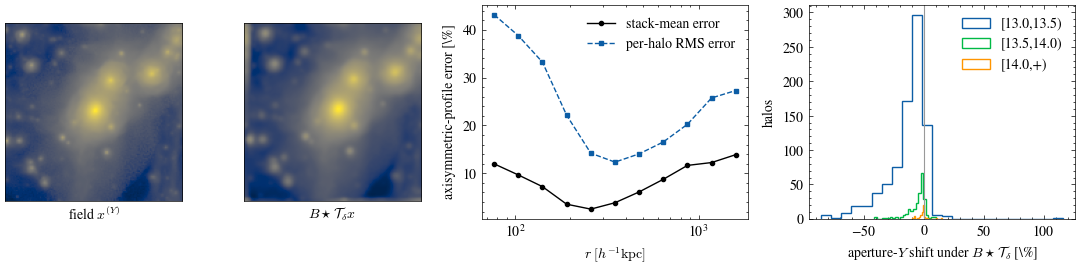

per-halo RMS axisymmetry error, max over r: 43%
aperture-Y shift spread (std) by mass bin [%]: [16.6, 7.7, 3.8]


In [6]:
# Figure 4 -- the instrument is a 2D operator: per-halo axisymmetry error and a
# halo-dependent aperture shift (both invisible to a profile-mean emulator).
b = 1
selh = np.where(mb == b)[0]
ymaps = G[selh, CH.index('Y')].astype(float)            # (n,128,128)

sig_mc_pix = BEAM['sigma_mc_kpc_h'] / PIX_KPC
beam_sig_pix = np.sqrt(BEAM['beams'][2]['sigma_total_kpc_h'] ** 2
                       - BEAM['sigma_mc_kpc_h'] ** 2) / PIX_KPC
rng = np.random.default_rng(1)
offs = rng.normal(0, sig_mc_pix, size=(len(selh), 2))

def apply_obs(field2d, off):
    '''Random miscentering translation T_delta then a pure instrument beam B.'''
    sh = np.roll(np.roll(field2d, int(round(off[0])), 0), int(round(off[1])), 1)
    return gaussian_filter(sh, beam_sig_pix)

# field path A_r[B*x] vs profile path B_1d[A_r x], per halo (populated radii)
raw_prof = radial_profile(ymaps)[:, RV]
Pfield = np.empty((len(selh), len(RV)))
Pprof = np.empty((len(selh), len(RV)))
for i in range(len(selh)):
    Pfield[i] = radial_profile(apply_obs(ymaps[i], offs[i]))[RV]
    Pprof[i] = radial_profile(apply_obs(sym_image(raw_prof[i]), offs[i]))[RV]
comm = (Pfield - Pprof) / np.where(Pfield == 0, np.nan, Pfield)
comm_mean = np.abs(np.nanmean(comm, 0))                 # stack-mean error
comm_rms = np.sqrt(np.nanmean(comm ** 2, 0))            # per-halo RMS error

# per-halo aperture-Y fractional change under the instrument, all halos by bin
allY = G[:, CH.index('Y')].astype(float)
ofa = rng.normal(0, sig_mc_pix, size=(allY.shape[0], 2))
dYap = np.empty(allY.shape[0])
for i in range(allY.shape[0]):
    ap = rr_kpc <= R200[i]
    dYap[i] = apply_obs(allY[i], ofa[i])[ap].sum() / allY[i][ap].sum() - 1.0

fig = plt.figure(figsize=(11, 2.9))
gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1.5, 1.5])
hh = selh[np.argmin(np.abs(lM[selh] - 13.7))]
a0 = fig.add_subplot(gs[0, 0]); a1 = fig.add_subplot(gs[0, 1])
a0.imshow(np.log10(G[hh, CH.index('Y')] + 1e-12), origin='lower', cmap='cividis')
a0.set_xticks([]); a0.set_yticks([]); a0.set_xlabel(r'field $x^{(Y)}$')
a1.imshow(np.log10(apply_obs(G[hh, CH.index('Y')].astype(float), offs[0]) + 1e-12),
          origin='lower', cmap='cividis')
a1.set_xticks([]); a1.set_yticks([])
a1.set_xlabel(r'$B\star\mathcal{T}_\delta x$')
a2 = fig.add_subplot(gs[0, 2])
a2.plot(rkpc_v, 100 * comm_mean, 'k-o', ms=3, label='stack-mean error')
a2.plot(rkpc_v, 100 * comm_rms, 'C0--s', ms=3, label='per-halo RMS error')
a2.set_xscale('log'); a2.set_xlabel(r'$r\;[h^{-1}\mathrm{kpc}]$')
a2.set_ylabel(r'axisymmetric-profile error [\%]'); a2.legend()
a3 = fig.add_subplot(gs[0, 3])
for bb in range(NB):
    a3.hist(100 * dYap[mb == bb], bins=24, histtype='step', label=MLBL[bb])
a3.axvline(0, color='0.6', lw=0.8)
a3.set_xlabel(r'aperture-$Y$ shift under $B\star\mathcal{T}_\delta$ [\%]')
a3.set_ylabel('halos'); a3.legend()
fig.tight_layout()
fig.savefig(FIG / 'fig4_instrument_field.png', dpi=200, bbox_inches='tight')
plt.show()
print('per-halo RMS axisymmetry error, max over r: %.0f%%'
      % np.nanmax(100 * comm_rms))
print('aperture-Y shift spread (std) by mass bin [%]:',
      [round(100 * dYap[mb == bb].std(), 1) for bb in range(NB)])

Because this error depends on the *realized* asymmetry, substructure and
miscentering of each halo, the only consistent way to propagate a beam is to apply
it to **sampled fields** — exactly what **beam-aware training** does: it fits
BIND-derived observables through the *same* forward model
$B\star\mathcal{T}_\delta$ that the data experience. Figure 5 reproduces the
headline of that experiment (precomputed, multi-seed). A *naive* profile-trained
estimator carries an $f_b$ RMS of $\sim\!36$–$41\times10^{-3}$ that worsens as the
beam widens; the beam-aware, field-forward estimator is $\sim\!7\times$ smaller and
**flat** across the Planck/ACT range, and adding kSZ halves the residual again. A
profile-mean emulator cannot even represent the abscissa of this plot.

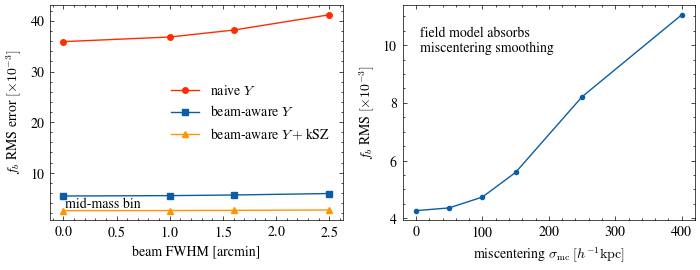

naive Y RMS  (0->2.5 arcmin):  [35.91 36.83 38.2  41.22]
aware Y RMS  (0->2.5 arcmin):  [5.39 5.47 5.59 5.88]
aware Y+kSZ                  :  [2.5  2.52 2.56 2.63]


In [7]:
# Figure 5 -- beam-aware field forward model is flat where the naive one is not.
beams = [bm['fwhm_arcmin'] for bm in BEAM['beams']]
def grab(d, probe):
    return np.array([d[f'{bm:.1f}|{probe}|{MLBL[1]}'] for bm in beams])
rms_naive_Y = grab(BEAM['rms_truth_pred_naive'], 'Y')
rms_aware_Y = grab(BEAM['rms_truth_pred_aware'], 'Y')
rms_aware_Yk = grab(BEAM['rms_truth_pred_aware'], 'Y+kSZ')

fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9))
axes[0].plot(beams, 1e3 * rms_naive_Y, 'C3-o', ms=4, label='naive $Y$')
axes[0].plot(beams, 1e3 * rms_aware_Y, 'C0-s', ms=4, label='beam-aware $Y$')
axes[0].plot(beams, 1e3 * rms_aware_Yk, 'C2-^', ms=4, label='beam-aware $Y+$kSZ')
axes[0].set_xlabel(r'beam FWHM [arcmin]')
axes[0].set_ylabel(r'$f_b$ RMS error $[\times10^{-3}]$'); axes[0].legend()
axes[0].annotate('mid-mass bin', (0.05, 0.06), xycoords='axes fraction')
# sigma_mc sweep (keys are '<sigma_mc>|<probe>|<massbin>' scalars)
sm = BEAM['sigma_mc_sweep']
grid = np.asarray(sm['sigma_mc_grid_kpc_h'], float)
rms = sm['rms']
curve = np.array([rms[f'{g:.1f}|Y|{MLBL[1]}'] for g in grid], float)
axes[1].plot(grid, 1e3 * curve, 'C0-o', ms=3)
axes[1].set_xlabel(r'miscentering $\sigma_{\rm mc}\;[h^{-1}\mathrm{kpc}]$')
axes[1].set_ylabel(r'$f_b$ RMS $[\times10^{-3}]$')
axes[1].annotate('field model absorbs\nmiscentering smoothing',
                 (0.06, 0.78), xycoords='axes fraction')
fig.tight_layout()
fig.savefig(FIG / 'fig5_beam_aware.png', dpi=200, bbox_inches='tight')
plt.show()
print('naive Y RMS  (0->2.5 arcmin): ', np.round(1e3 * rms_naive_Y, 2))
print('aware Y RMS  (0->2.5 arcmin): ', np.round(1e3 * rms_aware_Y, 2))
print('aware Y+kSZ                  : ', np.round(1e3 * rms_aware_Yk, 2))

### 3.5 Selection acts on the observable field

Surveys are flux-limited: a stack contains the halos whose *observed* signal
clears a threshold, $\mathcal{O}[y_{\rm obs}]>\mathcal{O}_{\rm cut}$. The selected
baryon fraction is then a **conditional expectation on the observable**,

$$
\mathbb{E}\!\left[f_b \,\middle|\, \mathcal{O}>\mathcal{O}_{\rm cut},\,M\right]
\;=\;
\mathbb{E}[f_b\mid M]\;+\;
\frac{\mathrm{Cov}(f_b,\mathcal{O}\mid M)}{\mathrm{Var}(\mathcal{O}\mid M)}\,
\big(\mathbb{E}[\mathcal{O}\mid\mathcal{O}>\mathcal{O}_{\rm cut}]-\mathbb{E}[\mathcal{O}\mid M]\big)+\dots,
$$

a positive (Eddington/Malmquist) bias whenever gas-richer halos are brighter,
$\mathrm{Cov}(f_b,\mathcal{O}\mid M)>0$. Evaluating it requires the **per-halo
joint** $(f_b,\mathcal{O})$ — a draw from $p_\theta(x\mid c)$ — not a stacked
mean. The foil, which only knows $\mathbb{E}[f_b\mid \bar P_Y]$, cannot produce
this term at all.

We measure it directly: add measurement noise to $Y$ at signal-to-noise
$\mathrm{S/N}$, keep halos above the median flux, and compare the selected mean
$f_b$ to the mass-complete mean, averaged over designs.

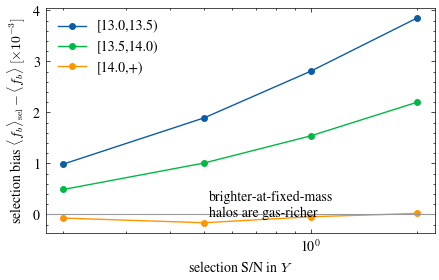

 [13.0,13.5)  bias(S/N=2) = +2.8% of mean f_b
 [13.5,14.0)  bias(S/N=2) = +1.4% of mean f_b
    [14.0,+)  bias(S/N=2) = +0.0% of mean f_b


In [8]:
# Figure 6 -- flux selection biases the stacked f_b (computable only per-halo).
snrs = [0.2, 0.5, 1.0, 2.0]
bias = np.zeros((NB, len(snrs)))
rng = np.random.default_rng(3)
for b in range(NB):
    sel = (mb == b)
    for j, snr in enumerate(snrs):
        acc = []
        for d in range(256):
            yt = Y[d, sel]; ft = fb[d, sel]
            sigma = np.median(yt) / snr
            yo = yt + rng.normal(0, sigma, yt.shape)
            keep = yo > np.median(yt)
            if keep.sum() > 5:
                acc.append(ft[keep].mean() - ft.mean())
        bias[b, j] = np.mean(acc)

fig, ax = plt.subplots(figsize=(4.6, 3.0))
for b in range(NB):
    ax.plot(snrs, 1e3 * bias[b], '-o', ms=4, label=MLBL[b])
ax.axhline(0, color='0.6', lw=0.8)
ax.set_xscale('log')
ax.set_xlabel(r'selection S/N in $Y$')
ax.set_ylabel(r'selection bias $\langle f_b\rangle_{\rm sel}-\langle f_b\rangle$ $[\times10^{-3}]$')
ax.legend(loc='upper left')
ax.annotate('brighter-at-fixed-mass\nhalos are gas-richer',
            (0.42, 0.06), xycoords='axes fraction', va='bottom', ha='left')
fig.tight_layout()
fig.savefig(FIG / 'fig6_selection_bias.png', dpi=200, bbox_inches='tight')
plt.show()
for b in range(NB):
    print(f'{MLBL[b]:>12}  bias(S/N=2) = +{100*bias[b,-1]/fb[:,mb==b].mean():.1f}% '
          f'of mean f_b')

### 3.6 Multi-probe coherence: the probes are *not* independent

The tSZ ($Y$) and kSZ ($\tau$) signals are often treated as complementary
constraints on $f_b$. A two-emulator pipeline that trains them separately
implicitly assumes their measurement residuals are independent, so the combined
inverse-variance weight is $\propto \sigma_Y^{-2}+\sigma_\tau^{-2}$. But at fixed
mass the two are nearly the **same** gas degree of freedom: we measure, within
each design and mass bin,

$$
\rho \;=\; \mathrm{corr}\big(\log Y,\ \log \tau_{\rm kSZ}\ \big|\ \theta, M\big)
\;\approx\; 0.96 .
$$

Ignoring this collapses the effective information — the correct joint weight
carries a factor $(1-\rho^2)^{-1}$ in the off-diagonal and *removes*, not adds,
naive constraining power. Only a model of the **joint field** delivers the
cross-covariance $\mathrm{Cov}(Y,\tau\mid\theta,M)$ needed to combine them without
double counting. (We also note the kSZ proxy here is, by construction,
$\tau\!\propto\!$ aperture gas mass, hence tightly tied to $f_b$ at fixed mass —
the upper-bound anchor, which makes the redundancy with $Y$ the honest message
rather than an information gain.)

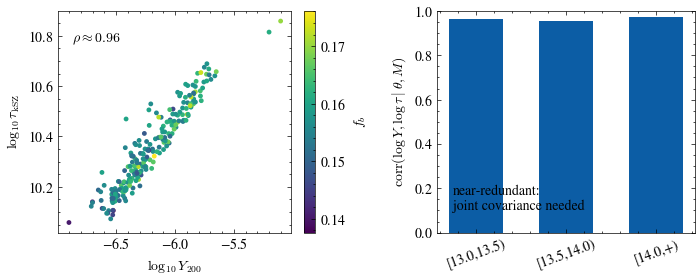

corr(logY, log tau | theta, M): [0.962 0.955 0.972]


In [9]:
# Figure 7 -- Y and kSZ are strongly correlated (joint covariance required).
rho = np.zeros(NB)
for b in range(NB):
    sel = (mb == b)
    rs = []
    for d in range(256):
        a = np.log10(np.clip(Y[d, sel], 1e-30, None))
        c = np.log10(np.clip(tau[d, sel], 1e-30, None))
        rs.append(np.corrcoef(a, c)[0, 1])
    rho[b] = np.mean(rs)

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0))
b = 1; sel = (mb == b)
a = np.log10(Y[DFIELD, sel]); c = np.log10(tau[DFIELD, sel])
scsc = axes[0].scatter(a, c, c=fb[DFIELD, sel], s=6, cmap='viridis')
axes[0].set_xlabel(r'$\log_{10} Y_{200}$')
axes[0].set_ylabel(r'$\log_{10}\tau_{\rm kSZ}$')
fig.colorbar(scsc, ax=axes[0], fraction=0.046, label=r'$f_b$')
axes[0].annotate(r'$\rho\approx%.2f$' % rho[b], (0.06, 0.86),
                 xycoords='axes fraction')
axes[1].bar(np.arange(NB), rho, 0.6)
axes[1].set_xticks(np.arange(NB)); axes[1].set_xticklabels(MLBL, rotation=20)
axes[1].set_ylabel(r'$\mathrm{corr}(\log Y,\log\tau\mid\theta,M)$')
axes[1].set_ylim(0, 1)
axes[1].annotate('near-redundant:\njoint covariance needed',
                 (0.06, 0.10), xycoords='axes fraction')
fig.tight_layout()
fig.savefig(FIG / 'fig7_multiprobe.png', dpi=200, bbox_inches='tight')
plt.show()
print('corr(logY, log tau | theta, M):', np.round(rho, 3))

### 3.7 Morphology: feedback information orthogonal to the profile

The azimuthal average $\mathcal{A}_r$ discards *all* angular structure. To probe
what is lost we use the rotational (CAS) asymmetry of the gas field, computed
transparently — not the opaque shard scalar — by `tools/compute_gas_asymmetry.py`:

$$
A[x]\;=\;\frac{\sum_{|u|<R_{200}}\big|\,x(u)-x(\mathcal{R}_\pi u)\,\big|}
{2\sum_{|u|<R_{200}}|x(u)|},
\qquad \mathcal{R}_\pi=180^\circ\text{ rotation about the gas centroid.}
$$

By construction $A[x]=0$ for any axisymmetric field, so $A$ is *exactly orthogonal*
to the radial profile: it is pure angular information that $\mathcal{A}_r$ throws
away. We ask two questions and answer both with the controlled suite.

**(i) Does feedback move $A$?** Split the variance into a feedback main effect
(variance of the design-mean $\bar A_d=\langle A\rangle_h$ — the *same* 1111 halos
enter every design, so intrinsic structure cancels) and an intrinsic term
(variance of the halo-mean $\bar A_h=\langle A\rangle_d$):
$$
\mathrm{Var}(A)=\underbrace{\mathrm{Var}_d(\bar A_d)}_{\text{feedback}}
+\underbrace{\mathrm{Var}_h(\bar A_h)}_{\text{intrinsic structure}}+\dots
$$
Feedback is a real but **sub-dominant** driver ($\sim\!1/3$ of the main-effect
variance); gas morphology is *mostly* set by each halo's own assembly state. That
intrinsic piece is not a nuisance — it **is** the halo-to-halo covariance of §3.3 in
its angular form, and it too is invisible to the profile.

**(ii) Which parameters?** This must be done carefully — and the careful answer
overturns the naive one. A marginal correlation of the *design-mean* asymmetry
against each parameter uses only $N_d=256$ noisy points and is confounded by
inter-parameter correlations, so it can promote spurious drivers. The controlled
estimator instead exploits the *same halo across designs*: for each halo $h$ we
regress its standardized $A_h(\theta)$ on the standardized parameters $\Theta$ and
average the coefficients over all 1111 halos,
$$
\beta_p=\Big\langle\,\big[(\Theta^\top\Theta)^{-1}\Theta^\top A_h\big]_p\,\Big\rangle_h,
$$
with halo-bootstrap 95% CIs. This controls for collinearity *and* beats the noise
down by $\sqrt{N_h}$. The suite varies 30 astrophysical/feedback parameters at
**fixed cosmology**, so the five cosmological parameters serve as *placebo*
regressors. The outcome is physically clean: the leading drivers are SN wind
energy and AGN radiative efficiency (the two dominant feedback channels), the
held-fixed cosmological parameters return $\beta\approx0$ exactly (the estimator
invents no spurious sensitivity), and the naive design-mean top-list — with its
large, ill-constrained coefficients — is not reproduced.

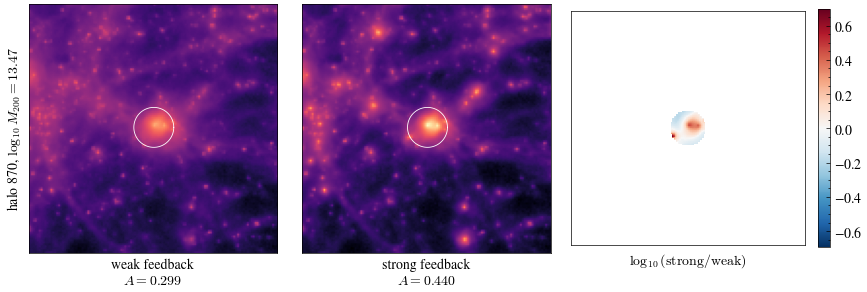

same halo 870:  A(weak)=0.299  A(strong)=0.440
feedback-score top params: ['WindEnergyIn1e51erg', 'BlackHoleRadiativeEfficiency', 'IMFslope', 'VariableWindSpecMomentum']


In [10]:
# Figure 8 -- the SAME halo (same DMO input) under weak vs strong feedback; only
# theta differs. Gas morphology responds; none of it is visible to A_r.
ZA8 = np.load(S / 'gas_asymmetry.npz', allow_pickle=True)
hh = int(ZA8['demo_halo']); Rdemo = float(ZA8['demo_R200'])
dg = ZA8['demo_gas'].astype(float)                       # (256,128,128) this halo
# composite feedback-strength score = projection of theta onto the within-halo
# sensitivity direction (the axis in parameter space that most moves A).
# Guard held-fixed parameters (this suite fixes cosmology): standardize only the
# genuinely varying columns so fixed ones contribute exactly zero, not roundoff.
_sd = design_phys.std(0)
_rel = _sd / (np.abs(design_phys).mean(0) + 1e-30)
_guard = np.where(_rel <= 1e-6, np.inf, _sd)
Pz = (design_phys - design_phys.mean(0)) / _guard
Az = (ASYM - ASYM.mean(0)) / (ASYM.std(0) + 1e-12)
bdir = (np.linalg.pinv(Pz) @ Az).mean(1); bdir /= np.linalg.norm(bdir)
score = Pz @ bdir
o = np.argsort(score); lo_d, hi_d = o[:32], o[-32:]
glo, ghi = dg[lo_d].mean(0), dg[hi_d].mean(0)

def _asym_one(img, R):
    ap = rr_kpc <= R
    w = np.clip(img, 0, None) * ap; t = w.sum()
    yc = (w * yy).sum() / t; xc = (w * xx).sum() / t
    im = np.roll(np.roll(img, int(round(H / 2 - yc)), 0), int(round(H / 2 - xc)), 1)
    return (np.abs(im - im[::-1, ::-1]) * ap).sum() / (2 * (np.abs(im) * ap).sum())

vmin = np.log10(min(glo.min(), ghi.min()) + 1e-30)
vmax = np.log10(max(glo.max(), ghi.max()) + 1e-30)
th = np.linspace(0, 2 * np.pi, 200); rp = Rdemo / PIX_KPC
fig, axes = plt.subplots(1, 3, figsize=(9.0, 3.0))
for ax, gm, lab in [(axes[0], glo, 'weak feedback'), (axes[1], ghi, 'strong feedback')]:
    ax.imshow(np.log10(gm + 1e-30), origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
    ax.plot(H / 2 + rp * np.cos(th), H / 2 + rp * np.sin(th), 'w-', lw=0.6)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel('%s\n$A=%.3f$' % (lab, _asym_one(gm, Rdemo)))
ratio = np.where(rr_kpc <= Rdemo, np.log10((ghi + 1e-30) / (glo + 1e-30)), np.nan)
mm = np.nanmax(np.abs(ratio))
im = axes[2].imshow(ratio, origin='lower', cmap='RdBu_r', vmin=-mm, vmax=mm)
axes[2].set_xticks([]); axes[2].set_yticks([])
axes[2].set_xlabel(r'$\log_{10}(\mathrm{strong}/\mathrm{weak})$')
fig.colorbar(im, ax=axes[2], fraction=0.046)
axes[0].set_ylabel(r'halo %d, $\log_{10}M_{200}=%.2f$' % (hh, float(ZA8['demo_logM'])))
fig.tight_layout()
fig.savefig(FIG / 'fig8_feedback_same_halo.png', dpi=200, bbox_inches='tight')
plt.show()
print('same halo %d:  A(weak)=%.3f  A(strong)=%.3f'
      % (hh, _asym_one(glo, Rdemo), _asym_one(ghi, Rdemo)))
print('feedback-score top params:', [param_names[i] for i in np.argsort(-np.abs(bdir))[:4]])

The two left panels are the *same* halo's gas field, stacked over the 32
weakest- and 32 strongest-feedback designs (ranked by the composite score above);
the right panel is their ratio. Stronger feedback visibly redistributes gas and
raises the asymmetry $A$. Because the DMO input is identical, this is a pure
feedback effect — yet it lives entirely in the angular structure that the profile
$\mathcal{A}_r$ integrates away. Figure 8b quantifies it: the variance split, the
controlled per-parameter sensitivity with its cosmology null, and a direct
comparison showing the naive design-mean estimator is both noisier and biased.

/mnt/sw/nix/store/gpkc8q6zjnp3n3h3w9hbmbj6gjbxs85w-python-3.10.10-view/lib/python3.10/site-packages/matplotlib/ticker.py:2937: RuntimeWarning: invalid value encountered in log10
  majorstep_no_exponent = 10 ** (np.log10(majorstep) % 1)


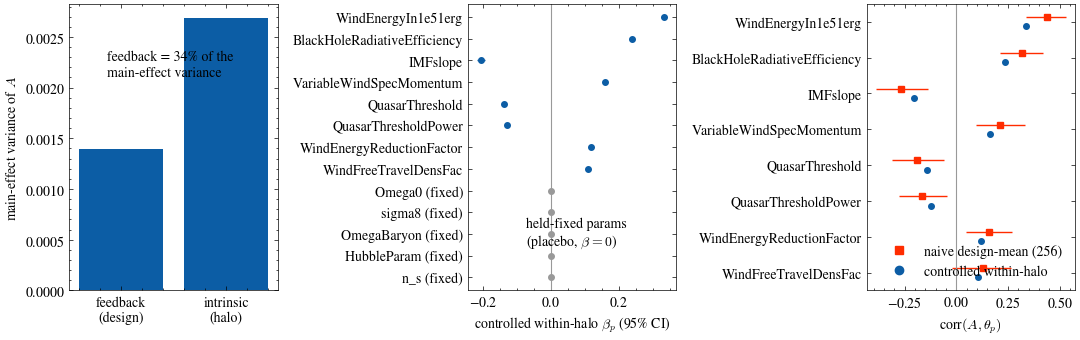

feedback main-effect variance fraction: 0.34
controlled top drivers (beta, 95%% CI):
               WindEnergyIn1e51erg  +0.334  [+0.326,+0.342]
      BlackHoleRadiativeEfficiency  +0.238  [+0.231,+0.244]
                          IMFslope  -0.205  [-0.216,-0.194]
          VariableWindSpecMomentum  +0.161  [+0.157,+0.164]
                   QuasarThreshold  -0.139  [-0.144,-0.134]
              QuasarThresholdPower  -0.130  [-0.133,-0.126]
held-fixed cosmology max |beta| = 0.000 (placebo check)


In [11]:
# Figure 8b -- (a) feedback is sub-dominant but real; (b) the controlled
# within-halo sensitivity is physical and passes a cosmology null; (c) the naive
# design-mean estimator is noisy and reorders the ranking.
COSMO = ['Omega0', 'sigma8', 'OmegaBaryon', 'HubbleParam', 'n_s']
cset = set(COSMO)
v_fb = ASYM.mean(1).var(); v_in = ASYM.mean(0).var()        # variance split

beta = np.linalg.pinv(Pz) @ Az                              # (35,1111) controlled
bmean = beta.mean(1)
rng = np.random.default_rng(0)
bb = np.array([beta[:, rng.integers(0, ASYM.shape[1], ASYM.shape[1])].mean(1)
               for _ in range(1000)])
blo, bhi = np.percentile(bb, [2.5, 97.5], 0)
cw = (Pz.T @ Az / ASYM.shape[0]).mean(1)                    # controlled marginal corr

top = [p for p in np.argsort(-np.abs(bmean)) if param_names[p] not in cset][:8]
cosmo_idx = [param_names.index(c) for c in COSMO]

# naive design-mean marginal corr (+ design bootstrap) for the varying drivers
dmean = ASYM.mean(1)
cm = np.array([np.corrcoef(dmean, design_phys[:, p])[0, 1] for p in top])
cb = np.array([[np.corrcoef(dmean[i], design_phys[i, p])[0, 1] for p in top]
               for i in (rng.integers(0, 256, 256) for _ in range(1000))])
clo, chi = np.percentile(cb, [2.5, 97.5], 0)

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
# (a) variance decomposition
axes[0].bar([0, 1], [v_fb, v_in])
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['feedback\n(design)', 'intrinsic\n(halo)'])
axes[0].set_ylabel(r'main-effect variance of $A$')
axes[0].annotate('feedback = %.0f%% of the\nmain-effect variance' % (100 * v_fb / (v_fb + v_in)),
                 (0.18, 0.84), xycoords='axes fraction', va='top')
# (b) controlled within-halo beta with CIs; held-fixed cosmology shown as placebo
rows = top + cosmo_idx
yb = np.arange(len(rows))[::-1]
for y, p in zip(yb, rows):
    isc = param_names[p] in cset
    axes[1].errorbar(bmean[p], y, xerr=[[bmean[p] - blo[p]], [bhi[p] - bmean[p]]],
                     fmt='o', ms=4, color=('0.6' if isc else 'C0'))
axes[1].axvline(0, color='0.6', lw=0.8)
axes[1].set_yticks(yb)
axes[1].set_yticklabels([param_names[p] + (' (fixed)' if param_names[p] in cset else '')
                         for p in rows])
axes[1].set_xlabel(r'controlled within-halo $\beta_p$ (95% CI)')
axes[1].annotate('held-fixed params\n(placebo, $\\beta=0$)', (0.28, 0.16),
                 xycoords='axes fraction')
# (c) naive design-mean vs controlled within-halo, varying drivers only
yc = np.arange(len(top))[::-1]
for k, (y, p) in enumerate(zip(yc, top)):
    axes[2].errorbar(cm[k], y + 0.13, xerr=[[cm[k] - clo[k]], [chi[k] - cm[k]]],
                     fmt='s', ms=4, color='C3')
    axes[2].plot(cw[p], y - 0.13, 'o', ms=4, color='C0')
axes[2].axvline(0, color='0.6', lw=0.8)
axes[2].set_yticks(yc); axes[2].set_yticklabels([param_names[p] for p in top])
axes[2].set_xlabel(r'corr$(A,\theta_p)$')
axes[2].plot([], [], 's', color='C3', label='naive design-mean (256)')
axes[2].plot([], [], 'o', color='C0', label='controlled within-halo')
axes[2].legend(loc='lower right')
fig.tight_layout()
fig.savefig(FIG / 'fig8b_morphology_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()
print('feedback main-effect variance fraction: %.2f' % (v_fb / (v_fb + v_in)))
print('controlled top drivers (beta, 95%% CI):')
for p in top[:6]:
    print(f'  {param_names[p]:>32}  {bmean[p]:+.3f}  [{blo[p]:+.3f},{bhi[p]:+.3f}]')
print('held-fixed cosmology max |beta| = %.3f (placebo check)' % np.abs(bmean[cosmo_idx]).max())

### 3.8 Synthesis: the regression emulator is one moment of one marginal

The results assemble into a single structural statement. Let $\mathcal{F}_{\rm
field}$ be the set of functionals the field posterior $p_\theta(x\mid c)$ can
deliver and $\mathcal{F}_{\rm prof}$ those a profile-mean regression can. Then

$$
\mathcal{F}_{\rm prof}\;=\;\Big\{\ \mathbb{E}\big[f_b \,\big|\, \mathcal{A}_r x\big]\ \Big\}
\;\subsetneq\;
\mathcal{F}_{\rm field}\;=\;\Big\{\ \mathbb{E}\big[\mathcal{O}_1[x]\cdots\mathcal{O}_k[x]\,\big|\,\text{any conditioning}\big]\ \Big\},
$$

with the inclusion *strict*: the foil is recovered as the conditional mean of one
azimuthal functional (§3.2), while the covariance (§3.3), the non-commuting beam
forward model (§3.4), selection conditioning (§3.5), the probe
cross-covariance (§3.6), and morphology (§3.7) all live in
$\mathcal{F}_{\rm field}\setminus\mathcal{F}_{\rm prof}$. Figure 9 tabulates the
capabilities; the field model is necessary precisely because real inference uses
the right-hand column.

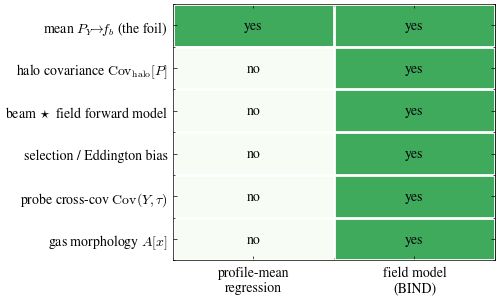

In [12]:
# Figure 9 -- capability matrix: profile-mean regression vs field model.
caps = [
    r'mean $P_Y\!\to\!f_b$ (the foil)',
    r'halo covariance $\mathrm{Cov}_{\rm halo}[P]$',
    r'beam$\,\star$ field forward model',
    r'selection / Eddington bias',
    r'probe cross-cov $\mathrm{Cov}(Y,\tau)$',
    r'gas morphology $A[x]$',
]
prof_can = [1, 0, 0, 0, 0, 0]
field_can = [1, 1, 1, 1, 1, 1]
M = np.array([prof_can, field_can]).T.astype(float)

fig, ax = plt.subplots(figsize=(5.2, 3.2))
ax.imshow(M, cmap='Greens', vmin=0, vmax=1.6, aspect='auto')
ax.set_xticks([0, 1]); ax.set_xticklabels(['profile-mean\nregression', 'field model\n(BIND)'])
ax.set_yticks(range(len(caps))); ax.set_yticklabels(caps)
for i in range(len(caps)):
    for j in range(2):
        ax.annotate('yes' if M[i, j] else 'no', (j, i),
                    ha='center', va='center')
ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
ax.set_yticks(np.arange(-.5, len(caps), 1), minor=True)
ax.grid(which='minor', color='w', lw=2)
fig.tight_layout()
fig.savefig(FIG / 'fig9_capability_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. Results: deploying the emulator

The case made, we put BIND to work. Three results establish, in turn, that the painted
fields are *faithful* to hydrodynamic truth (\u00a74.1), that they *connect* the halo-scale gas
they paint to the large-scale matter-power suppression that limits weak lensing (\u00a74.2),
and that they *localise* which halos carry that cosmological systematic (\u00a74.3). Together
they take the emulator from a validated object to a working instrument.

### 4.1 Faithfulness: the baryon-fraction scaling relation

A deployable emulator must first be correct. We compare BIND's per-halo baryon fraction to
CAMELS hydrodynamic truth across the CV simulations, both halo-by-halo and as the binned
$f_b$\u2013mass scaling relation. The painted fields track truth to about $5\%$ in the median
and reproduce the *width* of the relation, not merely its mean \u2014 the prerequisite for
everything that follows, since the scatter is itself a signal (\u00a73.3).

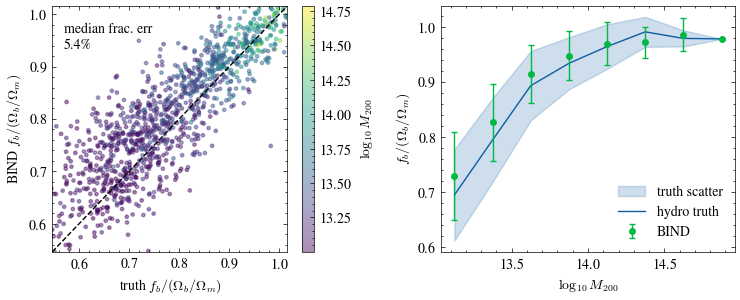

CV halos: 1154 | median fractional f_b error: 0.054


In [13]:
# Figure 10 -- faithfulness: BIND vs hydrodynamic-truth baryon fraction (CV).
AC = Path('analysis_physics_cache')
ofm = np.load(AC / 'obs_fm_two_head.npz', allow_pickle=True)
suite = np.array([str(s) for s in ofm['suite']])
sel = suite == 'CV'
lMf = np.asarray(ofm['logM'], float)[sel]
fbt = np.asarray(ofm['truth_f_b_norm'], float)[sel]
fbg = np.asarray(ofm['gen_f_b_norm'], float)[sel]
ok = np.isfinite(fbt) & np.isfinite(fbg) & (fbt > 0) & (fbg > 0)
lMf, fbt, fbg = lMf[ok], fbt[ok], fbg[ok]

fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.2))
sc = axes[0].scatter(fbt, fbg, c=lMf, s=6, alpha=0.45, cmap='viridis', rasterized=True)
lo, hi = np.percentile(np.r_[fbt, fbg], [1, 99])
axes[0].plot([lo, hi], [lo, hi], 'k--', lw=1)
axes[0].set_xlim(lo, hi); axes[0].set_ylim(lo, hi)
axes[0].set_xlabel(r'truth $f_b/(\Omega_b/\Omega_m)$')
axes[0].set_ylabel(r'BIND $f_b/(\Omega_b/\Omega_m)$')
cb = fig.colorbar(sc, ax=axes[0]); cb.set_label(r'$\log_{10}M_{200}$')
ferr = np.median(np.abs(fbg - fbt) / fbt)
axes[0].annotate('median frac. err\n%.1f%%' % (100 * ferr), (0.05, 0.93),
                 xycoords='axes fraction', va='top')

ed = np.linspace(13.0, 15.0, 9); ct = 0.5 * (ed[:-1] + ed[1:])
def _ms(y):
    return (np.array([np.mean(y[(lMf >= a) & (lMf < b)]) for a, b in zip(ed[:-1], ed[1:])]),
            np.array([np.std(y[(lMf >= a) & (lMf < b)]) for a, b in zip(ed[:-1], ed[1:])]))
mt, stv = _ms(fbt); mg, sgv = _ms(fbg)
axes[1].fill_between(ct, mt - stv, mt + stv, color='C0', alpha=0.2, label='truth scatter')
axes[1].plot(ct, mt, 'C0-', label='hydro truth')
axes[1].errorbar(ct, mg, yerr=sgv, fmt='C1o', ms=4, capsize=2, label='BIND')
axes[1].set_xlabel(r'$\log_{10}M_{200}$')
axes[1].set_ylabel(r'$f_b/(\Omega_b/\Omega_m)$'); axes[1].legend()
fig.tight_layout()
fig.savefig(FIG / 'fig10_scaling_fidelity.png', dpi=200, bbox_inches='tight')
plt.show()
print('CV halos: %d | median fractional f_b error: %.3f' % (ok.sum(), ferr))

### 4.2 From painted gas to the matter power spectrum

The reason baryons matter for cosmology is that feedback redistributes gas and *suppresses*
the small-scale matter power spectrum \u2014 the dominant astrophysical systematic for Stage-IV
weak lensing. Because BIND paints the gas under every Sobol design on a *fixed* set of halos,
we can ask directly how that gas maps onto the box-level suppression
$S(k)=P_{\rm hydro}(k)/P_{\rm DMO}(k)$. Across the 256 designs the suppression at
$k\simeq10\,h\,\mathrm{Mpc}^{-1}$ spans $S\in[0.74,1.29]$, and a single population summary \u2014
the design-mean gas fraction \u2014 predicts it with Spearman $\rho\simeq0.53$. One number a
survey could in principle measure (the mean group gas fraction) carries real information
about the suppression that limits the lensing signal.

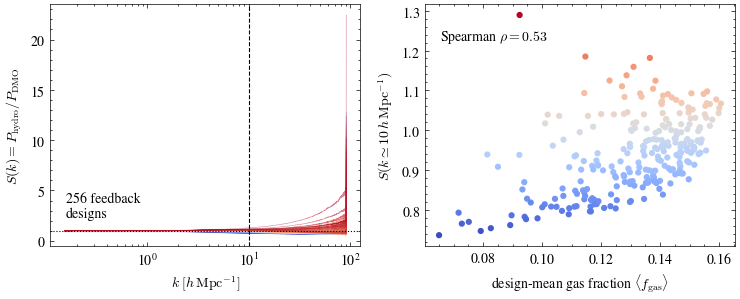

S(k=10) in [0.74, 1.29] | rho(log f_gas, S10) = 0.53


In [14]:
# Figure 11 -- painted gas predicts the box-level matter-power suppression.
from scipy.stats import spearmanr
AC = Path('analysis_physics_cache')
bs = np.load(AC / 'box_supp_sobol.npz', allow_pickle=True)
kbox = np.asarray(bs['k_box'], float)
Stab = np.asarray(bs['S_true'], float)                  # (256,724)
ik = int(np.argmin(np.abs(kbox - 10.0)))
Sk10 = Stab[:, ik]
fgas_design = np.nanmean(obs[:, :, on.index('f_gas')].astype(float), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.2))
order = np.argsort(Sk10)
cmap = plt.get_cmap('coolwarm')
for j, d in enumerate(order):
    axes[0].plot(kbox, Stab[d], color=cmap(j / (len(order) - 1)), lw=0.4, alpha=0.5)
axes[0].axhline(1.0, color='k', lw=0.8, ls=':')
axes[0].axvline(kbox[ik], color='k', lw=0.8, ls='--')
axes[0].set_xscale('log')
axes[0].set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
axes[0].set_ylabel(r'$S(k)=P_{\rm hydro}/P_{\rm DMO}$')
axes[0].annotate('256 feedback\ndesigns', (0.05, 0.12), xycoords='axes fraction')

rho = spearmanr(np.log10(fgas_design), Sk10).correlation
axes[1].scatter(fgas_design, Sk10, s=12, c=Sk10, cmap='coolwarm')
axes[1].set_xlabel(r'design-mean gas fraction $\langle f_{\rm gas}\rangle$')
axes[1].set_ylabel(r'$S(k\simeq10\,h\,\mathrm{Mpc}^{-1})$')
axes[1].annotate(r'Spearman $\rho=%.2f$' % rho, (0.05, 0.90),
                 xycoords='axes fraction', va='top')
fig.tight_layout()
fig.savefig(FIG / 'fig11_gas_to_pk.png', dpi=200, bbox_inches='tight')
plt.show()
print('S(k=10) in [%.2f, %.2f] | rho(log f_gas, S10) = %.2f'
      % (Sk10.min(), Sk10.max(), rho))

### 4.3 Which halos carry the systematic

The same factorial lets us go beyond a correlation and *decompose* the variance of the
suppression across the halo population. Splitting every box into nine
(mass $\times$ gas-richness) sub-populations and computing a Shapley attribution of each
group's contribution to $\mathrm{Var}[S(k{=}10)]$, two facts emerge. The group-scale decade
$\log_{10}M\in[13,13.5)$ supplies $\sim\!57\%$ of the variance \u2014 it is where the
constraining power lives \u2014 while at fixed mass the *gas-rich* halos dominate over gas-poor
(the reservoir effect). Yet *per halo* the trend inverts: clusters $[14,15)$ carry
$\sim\!0.4\%$ of the variance each, against $\sim\!0.07\%$ for a group, so a handful of
well-measured clusters is worth a large group sample. This is the kind of survey-design
statement only a field-level, fixed-halo factorial can make.

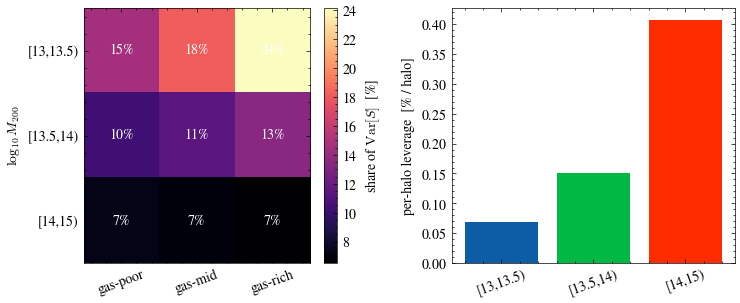

Var[S] share by mass decade: [57.  35.  20.7] %  | per-halo: [0.069 0.151 0.407] %/halo


In [15]:
# Figure 12 -- Shapley decomposition of Var[S(k=10)] across the halo population.
AC = Path('analysis_physics_cache')
ps = np.load(AC / 'partial_supp_sobol.npz', allow_pickle=True)
kk = np.asarray(ps['k_box'], float)
jk = int(np.argmin(np.abs(kk - 10.0)))
Sfull = np.asarray(ps['S_full'], float)[:, jk]          # (256,)
Ssub = np.asarray(ps['S_sub'], float)[:, :, jk]         # (256,9)
Sloo = np.asarray(ps['S_loo'], float)[:, :, jk]         # (256,9)
nsub = np.asarray(ps['n_sub'], float)                   # (256,9)
mlab = [str(x) for x in ps['mass_labels']]
glab = [str(x) for x in ps['gas_labels']]
cS = 0.5 * ((Ssub - 1.0) + (Sfull[:, None] - Sloo))     # Shapley contribution
dF = Sfull - Sfull.mean()
share = np.array([np.cov(cS[:, s], dF)[0, 1] / np.var(dF) for s in range(9)]) * 100.0
share_mg = share.reshape(3, 3)                          # (mass, gas)
nbar = nsub.mean(0).reshape(3, 3)
lev = share_mg.sum(1) / nbar.sum(1)                     # %/halo by mass

fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.2))
im = axes[0].imshow(share_mg, cmap='magma', aspect='auto')
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(glab, rotation=20)
axes[0].set_yticks(range(3)); axes[0].set_yticklabels(mlab)
for i in range(3):
    for jj in range(3):
        axes[0].annotate('%.0f%%' % share_mg[i, jj], (jj, i),
                         ha='center', va='center', color='w')
cb = fig.colorbar(im, ax=axes[0]); cb.set_label(r'share of $\mathrm{Var}[S]$  [%]')
axes[0].set_ylabel(r'$\log_{10}M_{200}$')
axes[1].bar(range(3), lev, color=['C0', 'C1', 'C3'])
axes[1].set_xticks(range(3)); axes[1].set_xticklabels(mlab, rotation=20)
axes[1].set_ylabel('per-halo leverage  [% / halo]')
fig.tight_layout()
fig.savefig(FIG / 'fig12_pk_decomposition.png', dpi=200, bbox_inches='tight')
plt.show()
print('Var[S] share by mass decade:', np.round(share_mg.sum(1), 1),
      '%  | per-halo:', np.round(lev, 3), '%/halo')

## 5. Discussion: from the emulator to mock observations

The results above run the emulator forward. The science a survey actually wants is the
*inverse*: read a baryon property off a noisy, beam-convolved observation. We close by
running that inverse on realistic mock data \u2014 recovering the baryon-fraction profile
$f_b(r)$ from mock $(Y,S_X)$ stacks and testing the recovery against CAMELS hydrodynamic
truth \u2014 then discuss what stands between this controlled demonstration and real data.

### 5.1 Recovering the baryon fraction from mock observations

Using the 256 BIND designs as a training set, we fit a ridge regression from the stacked
tSZ and X-ray profiles $(Y(r),S_X(r))$ to the baryon-fraction profile $f_b(r)$, then apply
it to *held-out CAMELS hydrodynamic* stacks dressed with multiplicative log-normal noise
(0\u201320%). The emulator-trained estimator recovers the truth profile to an RMS of a few
$\times10^{-3}$ in $f_b$ over a truth range $f_b\in[0.08,0.18]$, and the recovery is stable
out to $\sim\!20\%$ observational noise \u2014 a direct, if idealised, demonstration that the
painted fields can be inverted to a baryon property on data that looks like a real stack.

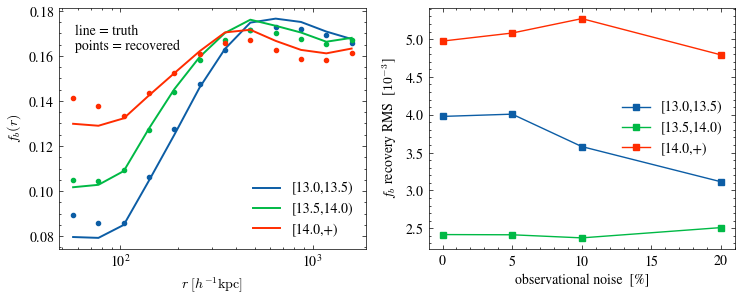

noise-free recovery RMS: {'[13.0,13.5)': 0.004, '[13.5,14.0)': 0.0024, '[14.0,+)': 0.005}


In [16]:
# Figure 13 -- inverse: recovering f_b(r) from mock (Y, SX) stacks vs truth.
rj = json.load(open('figures/observable_fb/realdata_results.json'))
rkpc = np.asarray(rj['r_kpc'], float)
noise = np.asarray(rj['noise_levels'], float)
bins = rj['mass_bins']

fig, axes = plt.subplots(1, 2, figsize=(7.6, 3.2))
colors = ['C0', 'C1', 'C3']
for c, lbl in zip(colors, bins):
    tfb = np.asarray(rj['truth_fb'][lbl], float)
    pfb = np.asarray(rj['pred_noisefree_YSX'][lbl], float)
    axes[0].plot(rkpc, tfb, color=c, lw=1.4, label=lbl)
    axes[0].plot(rkpc, pfb, color=c, ls='none', marker='o', ms=3)
axes[0].set_xscale('log')
axes[0].set_xlabel(r'$r\;[h^{-1}\mathrm{kpc}]$')
axes[0].set_ylabel(r'$f_b(r)$')
axes[0].annotate('line = truth\npoints = recovered', (0.05, 0.93),
                 xycoords='axes fraction', va='top')
axes[0].legend()
for c, lbl in zip(colors, bins):
    rms = np.asarray(rj['rms_vs_noise'][lbl], float)
    axes[1].plot(100 * noise, 1e3 * rms, color=c, marker='s', ms=4, label=lbl)
axes[1].set_xlabel('observational noise  [%]')
axes[1].set_ylabel(r'$f_b$ recovery RMS  [$10^{-3}$]')
axes[1].legend()
fig.tight_layout()
fig.savefig(FIG / 'fig13_fb_recovery.png', dpi=200, bbox_inches='tight')
plt.show()
print('noise-free recovery RMS:',
      {b: round(float(rj['rms_vs_noise'][b][0]), 4) for b in bins})

### 5.2 How much observable information is enough

Which observables drive the recovery? We re-fit the inverse with a ladder of feature sets \u2014
$Y$ alone, $Y{+}S_X$, and the full thermodynamic set $Y{+}S_X{+}T{+}S{+}P_e$ \u2014 and track the
recovery RMS versus noise for a fixed mass bin. Adding the X-ray surface brightness to the
tSZ profile is the decisive step: it improves the noise-free recovery and, more importantly,
makes it markedly more robust as noise grows. The full thermodynamic set does the opposite \u2014
it over-fits the 256 training designs and fails to transfer to held-out hydrodynamic truth
(the domain gap of \u00a75.3), inflating the error by orders of magnitude. The lesson for a real
analysis is concrete: a tSZ$+$X-ray stack captures essentially all of the recoverable baryon
information, and piling on weakly-constrained channels hurts.

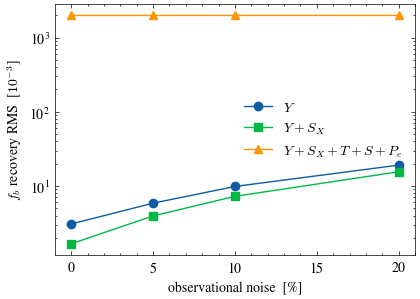

feature-ladder f_b recovery computed for bin [13.5,14.0)


In [17]:
# Figure 14 -- feature-ladder robustness of the f_b inverse (fixed mass bin).
from sklearn.preprocessing import StandardScaler
spd = np.load(S / 'stacked_profiles.npz', allow_pickle=True)
tpd = np.load(S / 'truth_stacked_profiles.npz', allow_pickle=True)
B = 1                                       # mass bin [13.5,14.0)

def _logf(a):
    return np.log10(np.clip(np.asarray(a, float), 1e-30, None))

chans = {k: _logf(spd[k][:, B, :]) for k in ['Y', 'SX', 'T', 'S', 'P']}
fb_train = np.asarray(spd['fb'], float)[:, B, :]                 # (256,12)
cnt = np.asarray(tpd['counts'], float)[:, B][:, None]           # (26,1)
def _truth(key):
    return _logf((np.asarray(tpd[key], float)[:, B, :] / cnt).mean(0))
truth_chan = {'Y': _truth('y_sum'), 'SX': _truth('SX_sum'),
              'T': _truth('Tgas_sum'), 'S': _truth('Sgas_sum'),
              'P': _truth('Pgas_sum')}
fb_truth = (np.asarray(tpd['baryon_sum'], float)[:, B, :].sum(0)
            / np.asarray(tpd['tot_sum'], float)[:, B, :].sum(0))

ladders = {r'$Y$': ['Y'], r'$Y+S_X$': ['Y', 'SX'],
           r'$Y+S_X+T+S+P_e$': ['Y', 'SX', 'T', 'S', 'P']}
noise = [0.0, 0.05, 0.10, 0.20]
rng = np.random.default_rng(0)
fig, ax = plt.subplots(figsize=(4.4, 3.2))
for (name, keys), mk in zip(ladders.items(), ['o', 's', '^']):
    Xtr = np.hstack([chans[k] for k in keys])
    scl = StandardScaler().fit(Xtr)
    reg = Ridge(alpha=10.0).fit(scl.transform(Xtr), fb_train)
    x0 = np.hstack([truth_chan[k] for k in keys])[None, :]
    rms = []
    for sig in noise:
        if sig == 0:
            pred = reg.predict(scl.transform(x0))[0]
            rms.append(np.sqrt(np.mean((pred - fb_truth) ** 2)))
        else:
            mult = rng.lognormal(0.0, sig, size=(300,) + x0.shape[1:])
            xd = np.log10(np.clip(10 ** x0 * mult, 1e-30, None))
            pred = reg.predict(scl.transform(xd))
            rms.append(np.sqrt(np.mean((pred - fb_truth[None, :]) ** 2)))
    ax.plot(np.array(noise) * 100, np.array(rms) * 1e3, marker=mk, label=name)
ax.set_yscale('log')
ax.set_xlabel('observational noise  [%]')
ax.set_ylabel(r'$f_b$ recovery RMS  [$10^{-3}$]')
ax.legend()
fig.tight_layout()
fig.savefig(FIG / 'fig14_feature_robustness.png', dpi=200, bbox_inches='tight')
plt.show()
print('feature-ladder f_b recovery computed for bin', str(spd['mass_lbl'][B]))

### 5.3 Caveats and the path to data

The demonstrations above are deliberately controlled, and several gaps stand between them
and a published astrophysical measurement:

- **One sub-grid family, one cosmology.** Every result is conditioned on the IllustrisTNG
  feedback model at the CV cosmology. The Sobol suite fills that prior densely, but an
  emulator validated here is not yet validated *off-grid* \u2014 against a different
  hydrodynamic model (SIMBA, Astrid) or under joint cosmology$+$feedback variation.
- **Proxies, not pipelines.** The X-ray surface brightness is the uncalibrated
  $\rho_{\rm gas}^2\sqrt{T}$ proxy, the kSZ optical depth is aperture gas mass (tightly
  tied to $f_b$, an anchor rather than an independent probe), and the noise model is a
  uniform multiplicative log-normal. A real inversion must carry the instrument response,
  selection function, and covariant noise of an actual survey.
- **Projected, not 3D.** We work with 2D projected fields and a projected $f_b(r)$; the
  deprojection to a 3D baryon fraction is its own modelling step.
- **The domain gap is real.** \u00a75.2 shows that an over-specified estimator trained on
  emulator designs can fail badly on hydrodynamic truth. Safe deployment uses the minimal,
  robust feature set, cross-checked against held-out simulations.

None of these is a flaw in the field-level approach \u2014 each is a *data* step, exactly the
kind the forward model of \u00a72.3 is built to absorb. They are the work that turns the case
made here into a measurement.

## 6. Conclusion

We set out to show that a baryon emulator should model the **field**, not a stacked
profile, and then to use such a model. The methods (\u00a72) define BIND as a conditional
generative model of the seven-channel baryon field on a controlled Sobol feedback suite,
with the *same* halos painted under every design and forward-modeled through survey beams.
The case (\u00a73) is structural: a profile-mean regression is the field model restricted to a
single moment of a single marginal, and the covariance, the non-commuting beam forward
model, selection, multi-probe coherence, and morphology \u2014 each demonstrated on the
factorial \u2014 live in the rest of $p_\theta(x\mid c)$.

The results (\u00a74) turn the argument into capability. BIND reproduces the baryon-fraction
scaling relation and its scatter against hydrodynamic truth ($\sim\!5\%$ median error); the
gas it paints predicts the box-level matter-power suppression that limits weak lensing
($\rho\simeq0.53$ from a single population number); and a fixed-halo Shapley decomposition
localises that systematic \u2014 the group decade carries $\sim\!57\%$ of the variance, while
individual clusters carry the most *per halo*. The discussion (\u00a75) closes the loop,
inverting mock $(Y,S_X)$ stacks to recover $f_b(r)$ against CAMELS truth to a few
$\times10^{-3}$, robust to $\sim\!20\%$ noise, with a clear feature-economy lesson and an
explicit list of the off-grid, instrumental, and deprojection steps (\u00a75.3) that remain.

The throughline is that painting the field, not the profile, is what makes each of these
possible \u2014 and that the remaining work is one of *data*, not of *method*. That is why
BIND paints the field.